In [ ]:
import pickle
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import networkx as nx
import torch
import numpy as np

from atomica.data.dataset import BlockGeoAffDataset, PDBDataset
from atomica.models.classifier_model import MultiClassClassifierModel, ClassifierModel
from atomica.trainers.abs_trainer import Trainer
from sklearn.metrics import precision_recall_curve, auc

AF3_ligands = ["ADP", "ATP", "GTP", "GDP", "FAD", "NAD", "NAP", "NDP", "HEM", "HEC", "PLM", "OLA", "MYR", "CIT", "CLA", "CHL", "BCL", "BCB"]
custom_colors = ['#7B2EF7', '#26CFC0', '#E65AFA', '#078C95', '#506DFF', '#FC6151', '#FC51A1', '#5AFFAE', '#FCE351', '#C89CFF', '#FC51BF', '#ADDEFF']

In [2]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio.SeqIO.FastaIO import FastaWriter

def pdb_to_fasta(pdb_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    output = {}

    # Open the FASTA file for writing
    for model in structure:
        for chain in model:
            sequence = ""
            for residue in chain:
                # Ensure the residue is an amino acid
                if PDB.is_aa(residue, standard=True):
                    sequence += seq1(residue.get_resname())
            
            # Create a sequence record for the chain
            seq_record = SeqRecord(
                Seq(sequence),
                id=f"{structure_id}_{chain.id}",
                description=f"Chain {chain.id}"
            )

            output[seq_record.id] = str(seq_record.seq)
    return output

In [11]:
parameter_tuned_versions = {
    "ADP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_325/",
    "ATP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_407/",
    "GTP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_416/",
    "GDP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_397/",
    "FAD": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_341/",
    "NAD": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_328/",
    "NAP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_344/",
    "NDP": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_423/",
    "HEM": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_386/",
    "HEC": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_362/",
    "CIT": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_347/",
    "CLA": "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/Pion_tune/version_428/",
}

In [ ]:
for ligand, version in parameter_tuned_versions.items():
    topk_file = f"{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/{ligand}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    with open(dataset_path, "rb") as f:
        test_dataset = pickle.load(f)

    predicted_ions = []
    for i in range(0, len(test_dataset), batch_size):
        end = min(i+batch_size, len(test_dataset))
        batch = PDBDataset.collate_fn([test_dataset[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ions.append(output)
    predicted_ions = torch.cat(predicted_ions, dim=0).squeeze()
    labels = np.array([int(test_dataset[i]['label']) for i in range(len(test_dataset))])
    precision, recall, _ = precision_recall_curve(labels, predicted_ions)
    auprc = auc(recall, precision)
    print(f"{ligand} AUPRC: {auprc} baseline: {np.mean(labels)}")

ADP AUPRC: 0.40649829881046384 baseline: 0.03165409482758621
ATP AUPRC: 0.19494960006745793 baseline: 0.04546542234984446
GTP AUPRC: 0.0059214556206759845 baseline: 0.001173853947856172
GDP AUPRC: 0.6932244516430819 baseline: 0.0293812976739806
FAD AUPRC: 0.8708620928692828 baseline: 0.03954496208017335
NAD AUPRC: 0.7463065945626487 baseline: 0.019259061120770363
NAP AUPRC: 0.38987895437471165 baseline: 0.014727722772277227
NDP AUPRC: 0.01850766627809929 baseline: 0.0033646183814414732
HEM AUPRC: 0.6615292337167662 baseline: 0.05029738815619343
HEC AUPRC: 0.739128452462315 baseline: 0.003593455323920689
CIT AUPRC: 0.0015943147393674808 baseline: 0.00175049597385926
CLA AUPRC: 0.005154639175257732 baseline: 5.1135201472693805e-05


In [3]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ligand.pkl", "rb") as f:
    dark_proteome_ligand = pickle.load(f)
len(dark_proteome_ligand)

969

In [5]:
dark_proteome_predictions = {}

for ligand, version in parameter_tuned_versions.items():
    topk_file = f"{version}/checkpoint/topk_map.txt"
    with open(topk_file, 'r') as f:
        topk_map = f.readlines()
    best_ckpt = topk_map[0].split()[1]
    dataset_path = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{ligand}/{ligand}_sequence_30_test.pkl"

    pion_model = torch.load(best_ckpt, map_location='cuda')
    batch_size = 16
    
    predicted_ligands = []
    for i in range(0, len(dark_proteome_ligand), batch_size):
        end = min(i+batch_size, len(dark_proteome_ligand))
        batch = PDBDataset.collate_fn([dark_proteome_ligand[j]['data'] for j in range(i, end)])
        batch = Trainer.to_device(batch, 'cuda')
        output = pion_model.infer(batch).detach().cpu()
        predicted_ligands.append(output)
    predicted_ligands = torch.cat(predicted_ligands, dim=0).squeeze()
    dark_proteome_predictions[ligand] = predicted_ligands
    print(f"{ligand} done")

ADP done
ATP done
GTP done
GDP done
FAD done
NAD done
NAP done
NDP done
HEM done
HEC done
CIT done
CLA done


ADP 3 969
ATP 0 969
GTP 0 969
GDP 8 969
FAD 2 969
NAD 0 969
NAP 0 969
NDP 0 969
HEM 33 969
HEC 12 969
CIT 0 969
CLA 4 969


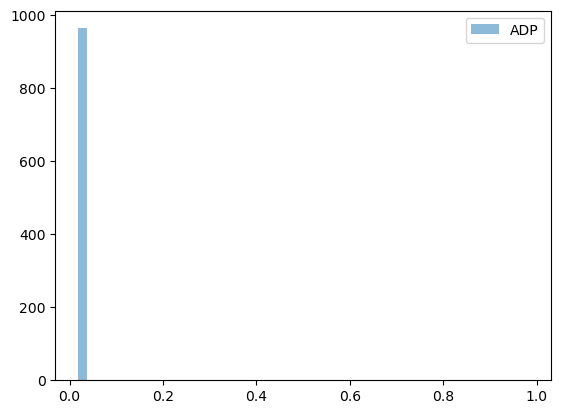

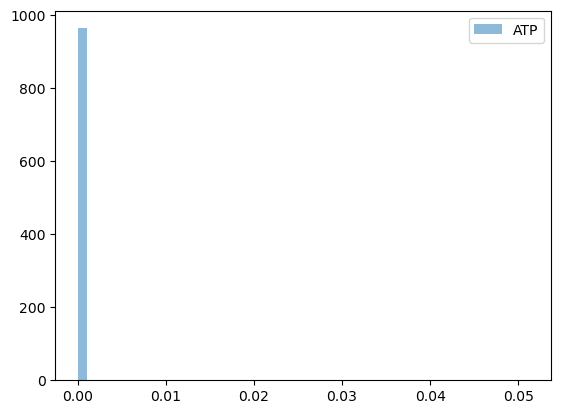

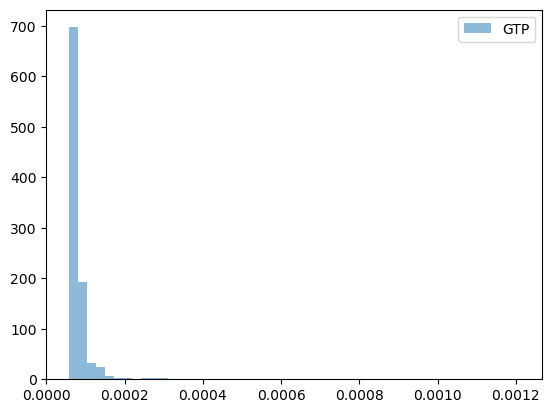

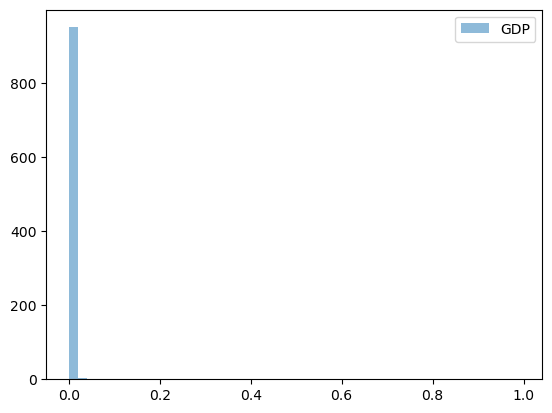

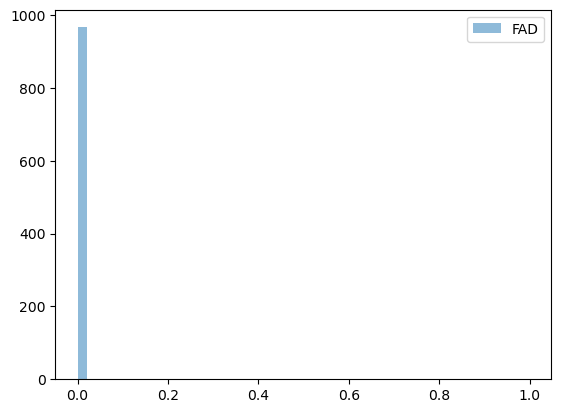

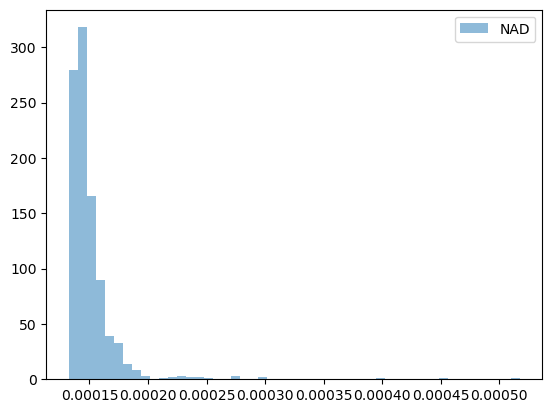

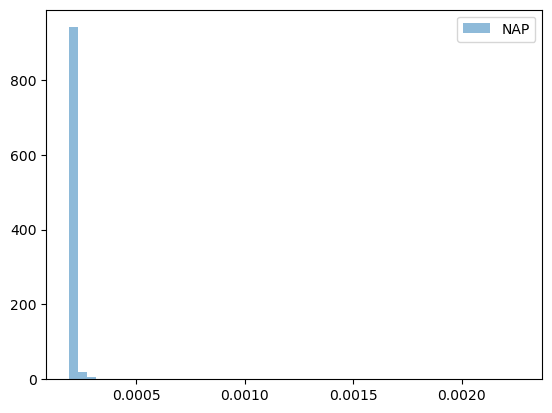

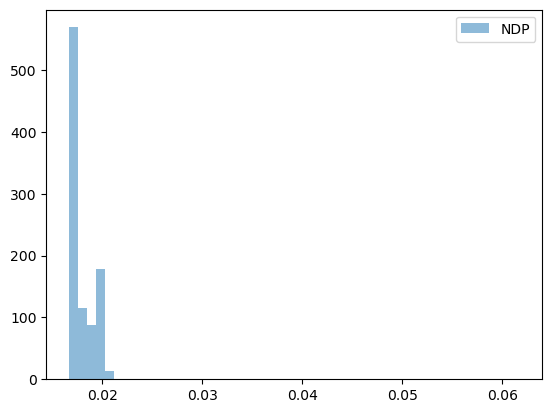

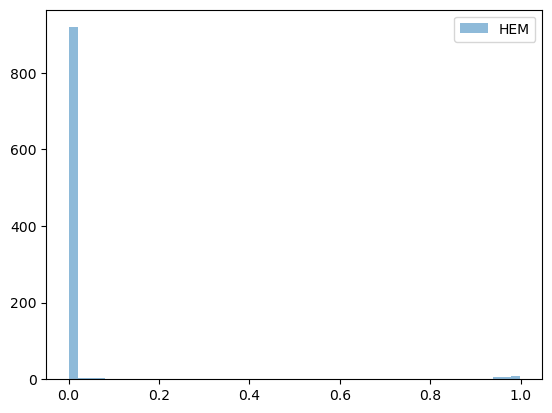

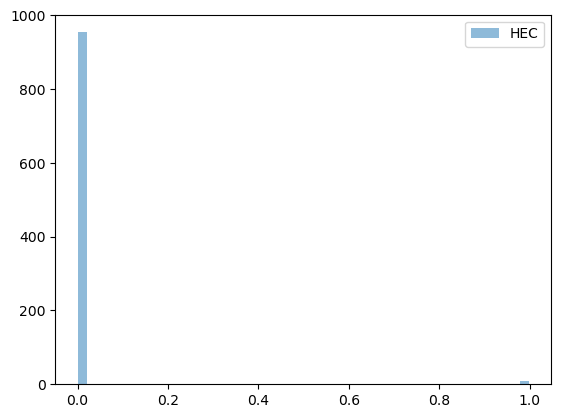

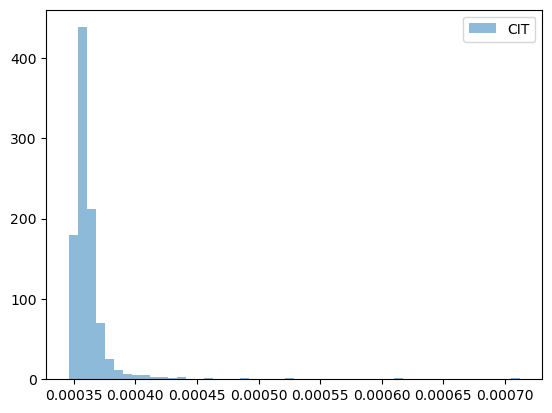

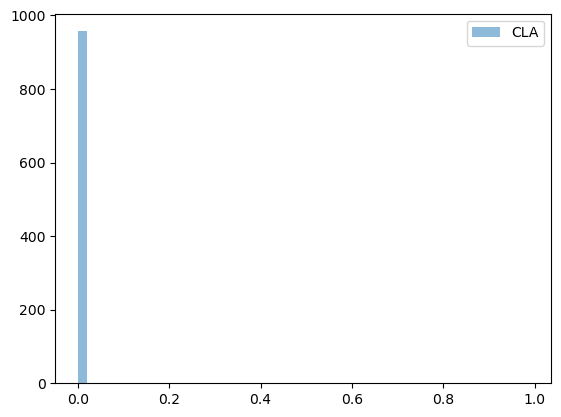

In [6]:
dark_proteome_ligand_ids = [x['id'] for x in dark_proteome_ligand]
dark_proteome_predictions_ids = {}
for ligand in AF3_ligands:
    if ligand not in dark_proteome_predictions:
        continue
    dark_proteome_predictions_ids[ligand] = []
    for i, pred in enumerate(dark_proteome_predictions[ligand]):
        if pred > 0.5:
            dark_proteome_predictions_ids[ligand].append(dark_proteome_ligand_ids[i])
    print(ligand, len(dark_proteome_predictions_ids[ligand]), len(dark_proteome_ligand))


for ligand in AF3_ligands:
    if ligand not in dark_proteome_predictions_ids:
        continue
    plt.hist(dark_proteome_predictions[ligand], bins=50, alpha=0.5, label=ligand)
    plt.legend()
    plt.show()

In [7]:
id_to_fasta = {}
all_ids = [x['id'] for x in dark_proteome_ligand]
for id in tqdm(all_ids, total=len(all_ids)):
    if id not in id_to_fasta:
        new_fasta = pdb_to_fasta(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{id}-F1-model_v4.pdb")
        id_to_fasta[id] = new_fasta[f'AF-{id}-F1-model_v4_A']

100%|██████████| 969/969 [00:48<00:00, 19.96it/s]


In [12]:
import pandas as pd
import json
import shutil
import random
random.seed(42)


for ligand in AF3_ligands:
    if ligand not in dark_proteome_predictions_ids:
        continue
    out_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/"
    os.makedirs(f"{out_dir}/outputs/model", exist_ok=True)
    os.makedirs(f"{out_dir}/outputs/reference", exist_ok=True)

    num_jobs = len(dark_proteome_predictions_ids[ligand])
    if num_jobs == 0:
        continue
    num_chunks = max(num_jobs//100, 1)
    chunk_size = num_jobs//num_chunks
    chunks = range(0, num_jobs+chunk_size, chunk_size)
    chunks = list(zip(chunks[:-1], chunks[1:]))
    chunks[-1] = (chunks[-1][0], num_jobs)

    dark_proteome_ligand_ids = [x['id'] for x in dark_proteome_ligand]
    random.shuffle(dark_proteome_ligand_ids)
    random_jobs = dark_proteome_ligand_ids[:num_jobs]

    # write AF3 format
    jobs = []
    for chunk_i, (start, end) in enumerate(chunks):
        os.makedirs(f"{out_dir}/inputs/model{chunk_i}", exist_ok=True)
        os.makedirs(f"{out_dir}/inputs/reference{chunk_i}", exist_ok=True)
        for idx in range(start, end):
            item_id = dark_proteome_predictions_ids[ligand][idx]
            if ligand == 'HEC':
                smiles = 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C'
                item_job1 = {
                    "name": item_id + '_model',
                    "modelSeeds": [1],
                    "sequences": [
                        {"protein": {"id": 'A', "sequence": id_to_fasta[item_id]}},
                        {"ligand": {"id": 'B', "smiles": smiles}},
                    ],
                    "dialect": "alphafold3",
                    "version": 1
                }
            else:
                item_job1 = {
                    "name": item_id + '_model',
                    "modelSeeds": [1],
                    "sequences": [
                        {"protein": {"id": 'A', "sequence": id_to_fasta[item_id]}},
                        {"ligand": {"id": ['B'], "ccdCodes": [ligand]}},
                    ],
                    "dialect": "alphafold3",
                    "version": 1
                }

            random_id = random_jobs[idx]
            if ligand == 'HEC':
                smiles = 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C'
                item_job2 = {
                    "name": random_id + '_reference',
                    "modelSeeds": [1],
                    "sequences": [
                        {"protein": {"id": 'A', "sequence": id_to_fasta[random_id]}},
                        {"ligand": {"id": 'B', "smiles": smiles}},
                    ],
                    "dialect": "alphafold3",
                    "version": 1
                }
            else:
                item_job2 = {
                    "name": random_id + '_reference',
                    "modelSeeds": [1],
                    "sequences": [
                        {"protein": {"id": 'A', "sequence": id_to_fasta[random_id]}},
                        {"ligand": {"id": ['B'], "ccdCodes": [ligand]}},
                    ],
                    "dialect": "alphafold3",
                    "version": 1
                }
            with open(f'{out_dir}/inputs/model{chunk_i}/{item_id}_model.json', 'w') as f:
                json.dump(item_job1, f, indent=2)
            with open(f'{out_dir}/inputs/reference{chunk_i}/{random_id}_reference.json', 'w') as f:
                json.dump(item_job2, f, indent=2)

## Analyse AF3 outputs

In [4]:
import os
from glob import glob

for ligand in AF3_ligands:
    print(ligand)
    model_output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/outputs/model"
    if not os.path.exists(model_output_dir):
        continue
    model_processed_items = os.listdir(model_output_dir)
    reference_output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/outputs/reference"
    reference_processed_items = os.listdir(reference_output_dir)

    all_reference = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/inputs/reference*/*.json")
    all_reference = [os.path.basename(x).replace('.json', '').lower() for x in all_reference]
    print(f"missing reference {len(set(all_reference) - set(reference_processed_items))} out of {len(set(all_reference))}, {len(all_reference)}")

    all_model = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/inputs/model*/*.json")
    all_model = [os.path.basename(x).replace('.json', '').lower() for x in all_model]
    print(f"missing model {len(set(all_model) - set(model_processed_items))} out of {len(set(all_model))}, {len(all_model)}")

ADP
missing reference 0 out of 3, 3
missing model 0 out of 3, 3
ATP
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
GTP
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
GDP
missing reference 0 out of 8, 8
missing model 0 out of 8, 8
FAD
missing reference 0 out of 2, 2
missing model 0 out of 2, 2
NAD
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
NAP
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
NDP
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
HEM
missing reference 0 out of 33, 33
missing model 0 out of 33, 33
HEC
missing reference 0 out of 12, 12
missing model 0 out of 12, 12
PLM
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
OLA
MYR
CIT
missing reference 0 out of 0, 0
missing model 0 out of 0, 0
CLA
missing reference 0 out of 4, 4
missing model 0 out of 4, 4
CHL
BCL
BCB


In [5]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ligand.pkl", "rb") as f:
    dark_proteome_ligand = pickle.load(f)
len(dark_proteome_ligand)

dark_proteome_ligand_ids = [x['id'] for x in dark_proteome_ligand]

Modeled uniprots 59 out of 969


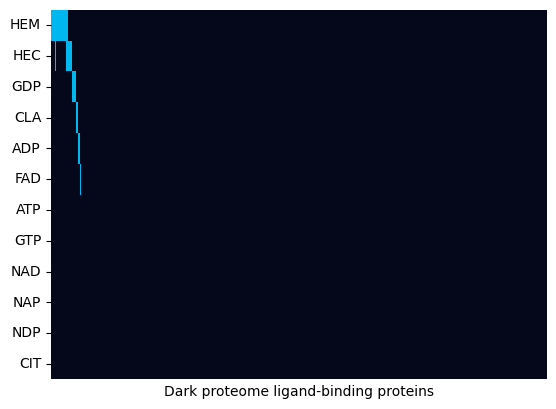

In [6]:
from glob import glob
AF3_ligands_tested = ['HEM', 'HEC', 'GDP', 'CLA', 'ADP', 'FAD', 'ATP', 'GTP', 'NAD', 'NAP', 'NDP', 'CIT']

heatmap = np.zeros((len(AF3_ligands_tested), len(dark_proteome_ligand)))
dark_proteome_ligand_ids_ordered = []
for ion_idx, ion in enumerate(AF3_ligands_tested):
    all_model = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ion}_v2/inputs/model*/*.json")
    for model in all_model:
        uniprot_id = os.path.basename(model).replace('_model.json', '')
        if uniprot_id not in dark_proteome_ligand_ids_ordered:
            dark_proteome_ligand_ids_ordered.append(uniprot_id)
        idx = dark_proteome_ligand_ids_ordered.index(uniprot_id)
        heatmap[ion_idx, idx] = 1
modeled_uniprots = sum(heatmap.sum(axis=0) > 0)
print(f"Modeled uniprots {modeled_uniprots} out of {len(dark_proteome_ligand)}")

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#05081A", '#00b7f0'])

ax = sns.heatmap(heatmap, cbar=False, cmap=cmap)
ax.set_yticklabels(AF3_ligands_tested)
plt.yticks(rotation=0)

ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel("Dark proteome ligand-binding proteins")
plt.show()


In [3]:
# analyse AF3 output
from glob import glob
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = []
for ligand in AF3_ligands:
    if not os.path.exists(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/"):
        continue
    model_outputs = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/outputs/model/**/*summary_confidences.json")
    reference_outputs = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/MLP_1_vs_other_{ligand}_v2/outputs/reference/**/*_summary_confidences.json")

    for fname in model_outputs:
        with open(fname, 'r') as f:
            data = json.load(f)
        id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
        iptm = data['iptm']
        ptm = data['ptm']
        with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
            data = json.load(f)
        if 'ccdCodes' in data['sequences'][1]['ligand']:
            ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
        else:
            ligand = data['sequences'][1]['ligand']['smiles']
            if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
                ligand = 'HEC'
        results_df.append({"ligand": ligand, "id": id_name.split("_")[0], "type": id_name.split("_")[1], "iptm": iptm, "ptm": ptm, "ligand": ligand})
    for fname in reference_outputs:
        with open(fname, 'r') as f:
            data = json.load(f)
        id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
        iptm = data['iptm']
        ptm = data['ptm']
        with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
            data = json.load(f)
        if 'ccdCodes' in data['sequences'][1]['ligand']:
            ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
        else:
            ligand = data['sequences'][1]['ligand']['smiles']
            if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
                ligand = 'HEC'
        results_df.append({"ligand": ligand, "id": id_name.split("_")[0], "type": id_name.split("_")[1], "iptm": iptm, "ptm": ptm, "ligand": ligand})

results_df = pd.DataFrame(results_df)

In [ ]:
results_df.to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/AF3_outputs/PL_AF3_scores.csv', index=False)
results_df[results_df.type == 'model'][['ligand', 'id', 'iptm', 'ptm']].to_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/AF3_outputs/PL_AF3_model_scores.csv', index=False)

In [44]:
foldseek_cluster = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/2-repId_isDark_nMem_repLen_avgLen_repPlddt_avgPlddt_LCAtaxId.tsv", sep="\t",
                                names= ["repID", "isDark", "nMem", "repLen", "avgLen", "repPlddt", "avgPlddt", "LCAtaxID"])
results_df['id'] = results_df['id'].apply(lambda x: x.upper())
results_df = results_df.merge(foldseek_cluster, left_on='id', right_on='repID', how='left')
results_df

,ligand,id,type,iptm,ptm,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
0,ADP,A0A0K1EAW9,model,0.86,0.66,A0A0K1EAW9,1,3,97,98.000,90.94,90.0200,2
1,ADP,A0A2W1LCZ4,model,0.92,0.89,A0A2W1LCZ4,1,2,122,122.000,92.62,90.9650,2
2,ADP,A0A843FLB4,model,0.82,0.69,A0A843FLB4,1,2,164,157.500,89.69,92.1900,131567
3,ADP,A0A0G1P162,reference,0.85,0.86,A0A0G1P162,1,3,101,97.000,94.25,90.5200,2
4,ADP,A0A449I4U7,reference,0.77,0.83,A0A449I4U7,1,42,98,97.000,94.31,90.8210,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,CLA,A8TRJ7,model,0.68,0.83,A8TRJ7,1,2,112,113.500,92.75,91.9050,28211
120,CLA,A0A2M8TSY9,reference,0.68,0.76,A0A2M8TSY9,1,39,196,204.744,94.88,92.3915,131567
121,CLA,A0A2S8BKT3,reference,0.74,0.86,A0A2S8BKT3,1,10,149,152.300,93.44,90.4950,1762
122,CLA,A0A833AM81,reference,0.55,0.71,A0A833AM81,1,2,164,163.000,91.31,90.3750,2


In [ ]:
cluster_assignments = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/1-AFDBClusters-entryId_repId_taxId_with_taxName.tsv.gz', compression='gzip', sep='\t')
cluster_ancestors = cluster_assignments[cluster_assignments['repId'].isin(results_df['repID'][results_df['type'] == 'model'])].groupby('repId').agg({'Ancestor': Counter}).reset_index()
cluster_ancestors

,repId,Ancestor
0,A0A0K1EAW9,{' Bacteria': 3}
1,A0A0K9IDB2,{' Bacteria': 8}
2,A0A0Q8RCH2,{' Bacteria': 4}
3,A0A1C6AUF5,{' Bacteria': 6}
4,A0A1F6GYS4,"{' Bacteria': 8, ' unclassified sequences': 1}"
5,A0A1F9ZBH5,{' Archaea': 2}
6,A0A1G0I1F9,{' Bacteria': 2}
7,A0A1G8Z1U8,{' Bacteria': 8}
8,A0A1G9T0A2,{' Archaea': 3}
9,A0A1L3RA87,{' Bacteria': 3}


In [45]:
results_df[results_df['type'] == 'model'].sort_values("iptm", ascending=False).head(20)

,ligand,id,type,iptm,ptm,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
101,HEC,B7S1B7,model,0.96,0.66,B7S1B7,1,3,333,335.000,90.12,90.2500,1706372
45,HEM,A0A4Q0VRF5,model,0.95,0.69,A0A4Q0VRF5,1,2,194,198.500,90.31,92.8450,1385
56,HEM,M7XJS0,model,0.95,0.93,M7XJS0,1,7,104,106.714,94.06,91.4271,976
93,HEC,A0A2E5W5C4,model,0.94,0.90,A0A2E5W5C4,1,2,90,90.500,92.62,91.5600,1783270
27,HEM,A0A0Q8RCH2,model,0.93,0.87,A0A0Q8RCH2,1,4,224,221.750,90.75,90.8125,1224
102,HEC,M7XJS0,model,0.93,0.93,M7XJS0,1,7,104,106.714,94.06,91.4271,976
100,HEC,A0A7Y8LED7,model,0.93,0.87,A0A7Y8LED7,1,3,504,480.667,90.00,90.4567,2
48,HEM,A0A6B2YTG2,model,0.93,0.90,A0A6B2YTG2,1,134,259,265.806,94.12,94.1024,131567
1,ADP,A0A2W1LCZ4,model,0.92,0.89,A0A2W1LCZ4,1,2,122,122.000,92.62,90.9650,2
92,HEC,A0A1T4N4K0,model,0.91,0.76,A0A1T4N4K0,1,2,103,98.500,91.19,90.7200,213422


In [42]:
results_df[results_df['type'] == 'model'].sort_values("nMem", ascending=False).head(20)

,ligand,id,type,iptm,ptm,repID,isDark,nMem,repLen,avgLen,repPlddt,avgPlddt,LCAtaxID
48,HEM,A0A6B2YTG2,model,0.93,0.90,A0A6B2YTG2,1,134,259,265.806,94.12,94.1024,131567
22,FAD,A0A2A4PEF3,model,0.65,0.77,A0A2A4PEF3,1,46,140,142.674,93.00,90.4985,2
47,HEM,A0A5K7Z5C1,model,0.81,0.74,A0A5K7Z5C1,1,35,152,153.086,90.69,92.2491,28221
41,HEM,A0A2V7V2X7,model,0.90,0.87,A0A2V7V2X7,1,31,165,163.839,92.94,92.1694,2
49,HEM,A0A6C0KYQ3,model,0.88,0.90,A0A6C0KYQ3,1,18,116,113.667,97.06,95.0167,0
51,HEM,A0A6I1R725,model,0.82,0.86,A0A6I1R725,1,18,122,122.222,95.62,92.5511,2
57,HEM,U2G347,model,0.77,0.86,U2G347,1,17,108,114.353,95.88,94.4200,2
38,HEM,A0A2D7XWJ9,model,0.88,0.84,A0A2D7XWJ9,1,15,235,231.533,93.81,95.1953,2
44,HEM,A0A3Q9I286,model,0.83,0.85,A0A3Q9I286,1,14,133,136.929,94.62,92.2086,1224
39,HEM,A0A2M7WER2,model,0.85,0.86,A0A2M7WER2,1,11,139,131.909,84.44,90.6018,1224


In [47]:
from scipy.stats import ks_2samp
model_data = results_df[results_df['type'] == 'model']['iptm']
reference_data = results_df[results_df['type'] == 'reference']['iptm']
ks_statistic, p_value = ks_2samp(model_data, reference_data)

print(f"iPTM KS Statistic: {ks_statistic}")
print(f"iPTM P-value: {p_value}")

model_data = results_df[results_df['type'] == 'model']['ptm']
reference_data = results_df[results_df['type'] == 'reference']['ptm']
ks_statistic, p_value = ks_2samp(model_data, reference_data)

print(f"PTM KS Statistic: {ks_statistic}")
print(f"PTM P-value: {p_value}")

iPTM KS Statistic: 0.5
iPTM P-value: 2.0823465920315534e-07
PTM KS Statistic: 0.16129032258064516
PTM P-value: 0.39806645355934955


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

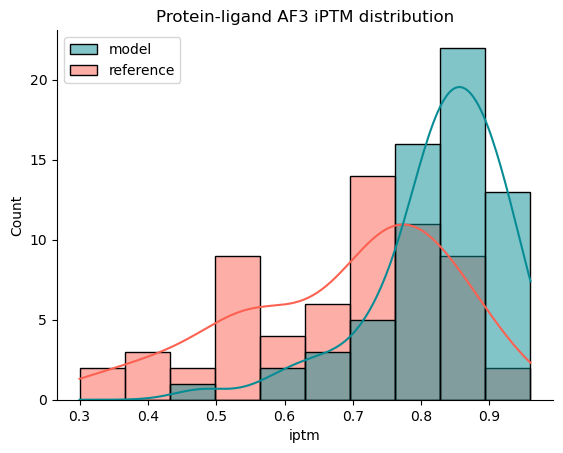

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

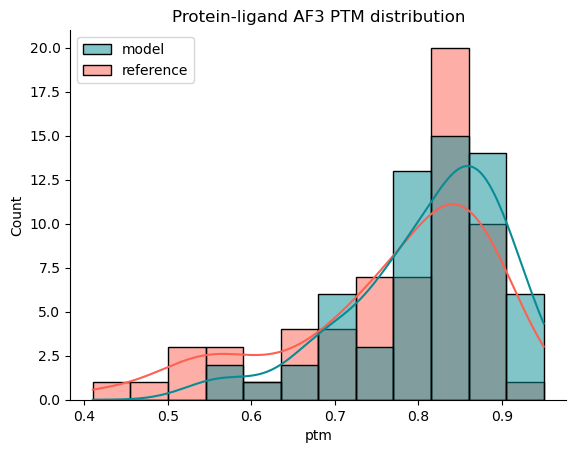

In [ ]:
sns.histplot(data=results_df, x='iptm', hue='type', common_norm=False, palette=[custom_colors[3], custom_colors[5]])
plt.title(f"Protein-ligand AF3 iPTM distribution")
plt.gca().get_legend().set_title('')
sns.despine()
plt.show()

sns.histplot(data=results_df, x='ptm', hue='type', common_norm=False, palette=[custom_colors[3], custom_colors[5]])
plt.title(f"Protein-ligand AF3 PTM distribution")
plt.gca().get_legend().set_title('')
sns.despine()
plt.show()

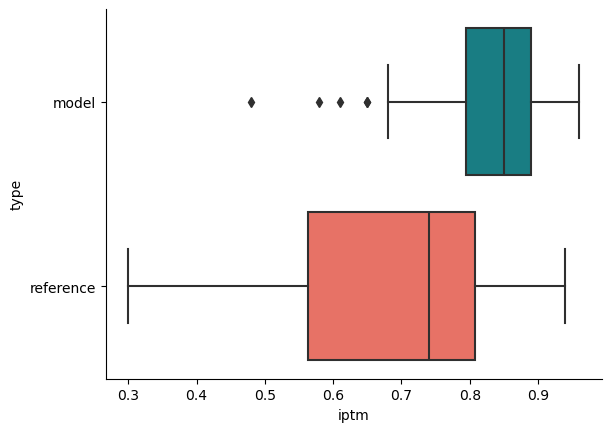

In [8]:
sns.boxplot(data=results_df, x='iptm', y='type', palette=[custom_colors[3], custom_colors[5]])
sns.despine()

In [10]:
results_df.groupby(['ligand', 'type'])[['iptm', 'ptm']].agg(['mean', 'std'])

iptm                 ptm          
                      mean       std      mean       std
ligand type                                             
ADP    model      0.866667  0.050332  0.746667  0.125033
       reference  0.756667  0.100664  0.800000  0.079373
CLA    model      0.655000  0.075939  0.765000  0.149108
       reference  0.570000  0.190613  0.685000  0.193649
FAD    model      0.565000  0.120208  0.730000  0.056569
       reference  0.765000  0.106066  0.835000  0.021213
GDP    model      0.805000  0.096658  0.815000  0.119642
       reference  0.767500  0.120683  0.823750  0.074438
HEC    model      0.873333  0.069326  0.827500  0.081589
       reference  0.752500  0.081478  0.798333  0.091932
HEM    model      0.849697  0.051325  0.823030  0.076096
       reference  0.645758  0.172210  0.749091  0.130895

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

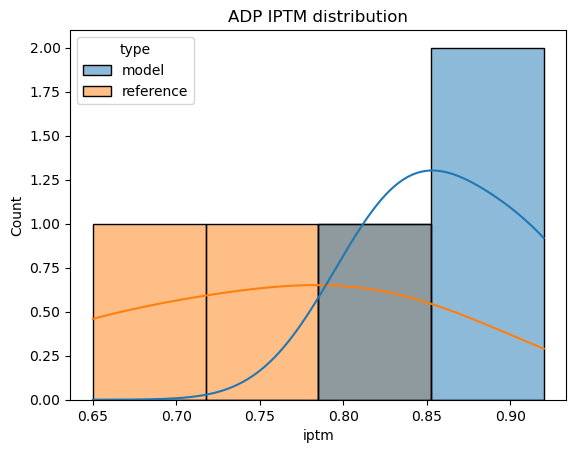

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

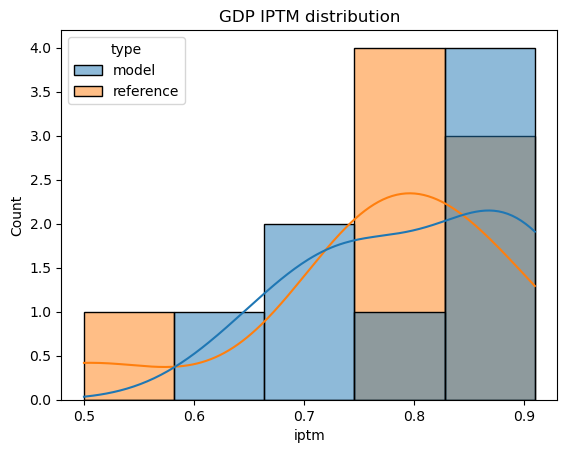

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

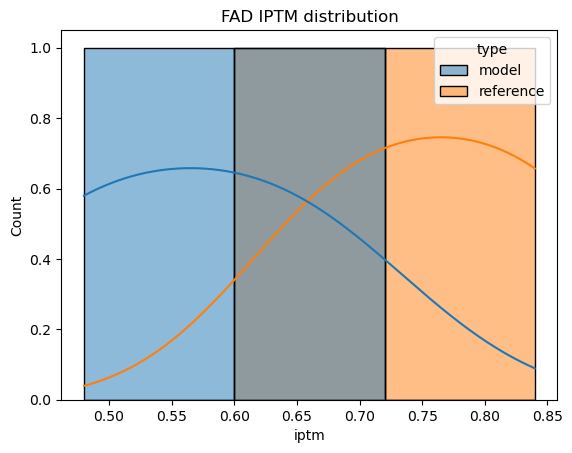

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

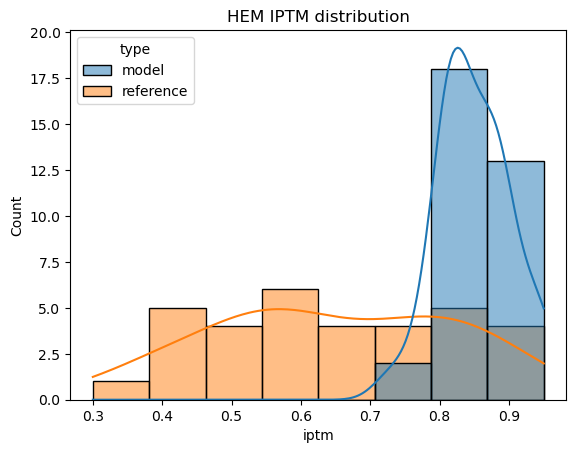

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

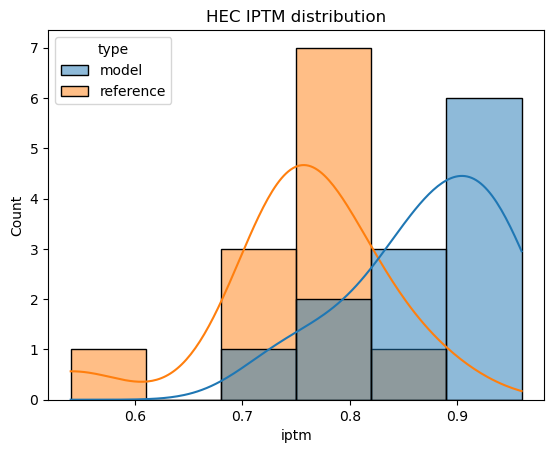

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

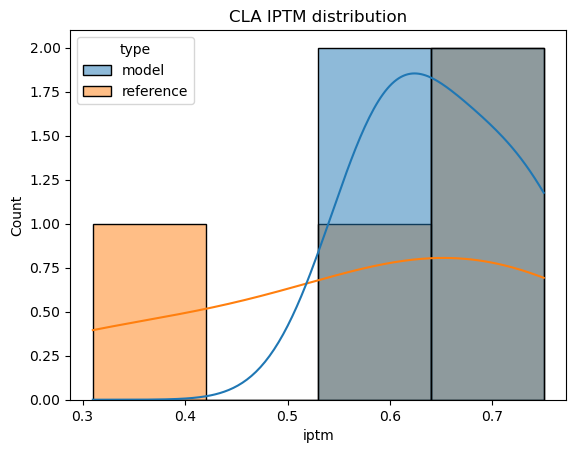

In [11]:
for ligand in results_df['ligand'].unique():
    sns.histplot(data=results_df[results_df['ligand'] == ligand], x='iptm', hue='type', kde=True, common_norm=False)
    plt.title(f"{ligand} IPTM distribution")
    plt.show()